In [1]:
import pandas as pd
import numpy as np

teams_df = pd.read_csv('../data/processed/teams.csv')

print(teams_df[['ppda', 'ppda_allowed', 'deep', 'deep_allowed']].describe())

               deep  deep_allowed
count  17964.000000  17964.000000
mean       6.388666      6.388666
std        4.294873      4.294873
min        0.000000      0.000000
25%        3.000000      3.000000
50%        6.000000      6.000000
75%        9.000000      9.000000
max       37.000000     37.000000


In [2]:
print(teams_df.columns.tolist())

['h_a', 'xG', 'xGA', 'npxG', 'npxGA', 'ppda', 'ppda_allowed', 'deep', 'deep_allowed', 'scored', 'missed', 'xpts', 'result', 'date', 'wins', 'draws', 'loses', 'pts', 'npxGD', 'team_id', 'team_name', 'league', 'year']


In [4]:
print(teams_df[['ppda', 'ppda_allowed']].describe())

                           ppda             ppda_allowed
count                     17964                    17964
unique                     7628                     7628
top     {'att': 236, 'def': 22}  {'att': 236, 'def': 22}
freq                         13                       13


In [5]:
# find one date+league+year with exactly 2 rows (i.e. one full match)
counts = teams_df.groupby(['date', 'league', 'year']).size()
sample_key = counts[counts == 2].index[0]

sample_rows = teams_df[
    (teams_df['date'] == sample_key[0]) &
    (teams_df['league'] == sample_key[1]) &
    (teams_df['year'] == sample_key[2])
]

print(sample_rows[['team_name', 'h_a', 'deep', 'deep_allowed', 'ppda', 'ppda_allowed']])

     team_name h_a  deep  deep_allowed                     ppda  \
7088    Nantes   a     2             0  {'att': 299, 'def': 23}   
7240  Bordeaux   h     0             2  {'att': 318, 'def': 13}   

                 ppda_allowed  
7088  {'att': 318, 'def': 13}  
7240  {'att': 299, 'def': 23}  


In [6]:
import ast

def parse_ppda(val):
    d = ast.literal_eval(val) if isinstance(val, str) else val
    return d['att'] / d['def'] if d['def'] != 0 else np.nan

teams_df['ppda_value'] = teams_df['ppda'].apply(parse_ppda)
teams_df['ppda_allowed_value'] = teams_df['ppda_allowed'].apply(parse_ppda)

print(teams_df[['ppda_value', 'ppda_allowed_value']].describe())

         ppda_value  ppda_allowed_value
count  17962.000000        17962.000000
mean      12.772308           12.772308
std        7.148160            7.148160
min        2.083333            2.083333
25%        8.173913            8.173913
50%       11.217391           11.217391
75%       15.454545           15.454545
max      193.000000          193.000000


In [7]:
print((teams_df['ppda_value'] > 50).sum(), 'rows with ppda > 50')
print(teams_df[teams_df['ppda_value'] > 50][['team_name', 'league', 'year', 'ppda_value']].head(10))

48 rows with ppda > 50
             team_name      league  year  ppda_value
1901  Bayer Leverkusen  bundesliga  2023   66.600000
2166         Wolfsburg  bundesliga  2023   50.666667
2356      Union Berlin  bundesliga  2023  105.000000
2560          Augsburg  bundesliga  2024   56.142857
2961     FC Heidenheim  bundesliga  2024   59.200000
2970     FC Heidenheim  bundesliga  2024   56.000000
3052         St. Pauli  bundesliga  2024   61.500000
3812             Cadiz     la_liga  2020   50.285714
4711            Getafe     la_liga  2022   82.800000
5199            Girona     la_liga  2022   56.800000


In [8]:
print(teams_df[(teams_df['team_name'] == 'Union Berlin') & (teams_df['year'] == 2023) & (teams_df['ppda_value'] == 105.0)][['team_name', 'date', 'ppda', 'ppda_value']])

         team_name                 date                    ppda  ppda_value
2356  Union Berlin  2023-11-12 14:30:00  {'att': 525, 'def': 5}       105.0


In [9]:
print(teams_df[teams_df['ppda_value'].isna()][['team_name', 'league', 'year', 'ppda']])

          team_name      league  year                  ppda
2944         Bochum  bundesliga  2024  {'att': 0, 'def': 0}
3012  Holstein Kiel  bundesliga  2024  {'att': 0, 'def': 0}


In [10]:
teams_df['ppda_extraordinary'] = teams_df['ppda_value'] > 50
teams_df['ppda_allowed_extraordinary'] = teams_df['ppda_allowed_value'] > 50

print(teams_df['ppda_extraordinary'].value_counts())
print()
print(teams_df[teams_df['ppda_extraordinary']][['team_name', 'league', 'year', 'date', 'ppda_value']].sort_values('ppda_value', ascending=False))

ppda_extraordinary
False    17916
True        48
Name: count, dtype: int64

                     team_name          league  year                 date  \
13276         Sheffield United  premier_league  2023  2024-02-18 14:00:00   
16648                  Udinese         serie_a  2023  2023-12-09 19:45:00   
13271         Sheffield United  premier_league  2023  2023-12-30 15:00:00   
15047                  Bologna         serie_a  2021  2021-10-28 18:45:00   
2356              Union Berlin      bundesliga  2023  2023-11-12 14:30:00   
5582                  Valencia         la_liga  2023  2023-12-02 13:00:00   
13365        Nottingham Forest  premier_league  2023  2024-05-19 15:00:00   
16735                 Sassuolo         serie_a  2023  2024-02-28 17:00:00   
8587                    Angers         ligue_1  2022  2023-01-11 20:00:00   
4711                    Getafe         la_liga  2022  2023-01-22 17:30:00   
10572           Crystal Palace  premier_league  2020  2021-01-17 19:15:00   


In [11]:
print(teams_df['ppda_value'].isna().sum(), 'total NaN ppda rows — expected: 2')

2 total NaN ppda rows — expected: 2


In [12]:
ppda_by_league = teams_df.groupby('league')['ppda_value'].agg(['mean', 'median', 'std', 'count']).round(2)
print(ppda_by_league)

                 mean  median   std  count
league                                    
bundesliga      13.29   11.73  6.96   3058
la_liga         11.62   10.35  6.08   3800
ligue_1         12.92   11.33  6.82   3504
premier_league  13.29   11.50  8.44   3800
serie_a         12.85   11.33  7.05   3800


In [13]:
print(teams_df['ppda_value'].isna().sum(), 'total NaN ppda rows — expected: 2')

ppda_by_league = teams_df.groupby('league')['ppda_value'].agg(['mean', 'median', 'std', 'count']).round(2)
print(ppda_by_league)

2 total NaN ppda rows — expected: 2
                 mean  median   std  count
league                                    
bundesliga      13.29   11.73  6.96   3058
la_liga         11.62   10.35  6.08   3800
ligue_1         12.92   11.33  6.82   3504
premier_league  13.29   11.50  8.44   3800
serie_a         12.85   11.33  7.05   3800


In [14]:
ppda_clean = teams_df[~teams_df['ppda_extraordinary']]
ppda_by_league_clean = ppda_clean.groupby('league')['ppda_value'].agg(['mean', 'median', 'std', 'count']).round(2)
print(ppda_by_league_clean)

                 mean  median   std  count
league                                    
bundesliga      13.17   11.73  6.46   3051
la_liga         11.56   10.33  5.75   3796
ligue_1         12.84   11.33  6.51   3498
premier_league  13.00   11.46  6.90   3782
serie_a         12.65   11.33  6.10   3787


In [15]:
team_season_ppda = ppda_clean.groupby(['team_name', 'league', 'year']).agg(
    avg_ppda=('ppda_value', 'mean'),
    matches=('ppda_value', 'count')
).reset_index()

print(team_season_ppda.head())

  team_name   league  year   avg_ppda  matches
0  AC Milan  serie_a  2020  10.804890       38
1  AC Milan  serie_a  2021   9.251117       38
2  AC Milan  serie_a  2022   9.739950       38
3  AC Milan  serie_a  2023  12.060577       38
4  AC Milan  serie_a  2024  14.222186       38


In [17]:
team_season = pd.read_csv('../data/processed/team_season.csv')

pressing_correlation = team_season_ppda.merge(
    team_season[['team_name', 'league', 'year', 'xGD_attack', 'clinical_rate']],
    on=['team_name', 'league', 'year']
)

print(pressing_correlation.corr(numeric_only=True)[['avg_ppda']])
print()
print(pressing_correlation.shape)

               avg_ppda
year           0.106422
avg_ppda       1.000000
matches       -0.154767
xGD_attack     0.020717
clinical_rate -0.148146

(486, 7)


In [21]:
shots_df = pd.read_csv("/Users/aadvikmazumdar/Projects/OnTarget/data/processed/shots_enriched.csv")


team_counter_share = shots_df.groupby(['team_name', 'league', 'year']).agg(
    total_shots=('counter_tier', 'count'),
    counter_shots=('counter_score', lambda x: (x >= 2).sum()),
    counter_goals=('result', lambda x: ((x == 'Goal')).sum())  # placeholder, fix below
).reset_index()

# proper goals from counter shots specifically
counter_only = shots_df[shots_df['counter_score'] >= 2]
counter_goals = counter_only.groupby(['team_name', 'league', 'year']).agg(
    counter_goals=('result', lambda x: (x == 'Goal').sum())
).reset_index()

team_counter_share = team_counter_share.drop(columns='counter_goals').merge(
    counter_goals, on=['team_name', 'league', 'year'], how='left'
)
team_counter_share['counter_goals'] = team_counter_share['counter_goals'].fillna(0)

team_counter_share['counter_share'] = (team_counter_share['counter_shots'] / team_counter_share['total_shots']).round(4)
team_counter_share['counter_conversion'] = (team_counter_share['counter_goals'] / team_counter_share['counter_shots'].replace(0, np.nan)).round(4)

pressing_counter = team_season_ppda.merge(
    team_counter_share, on=['team_name', 'league', 'year']
)

print(pressing_counter.corr(numeric_only=True)[['avg_ppda']])

                    avg_ppda
year                0.106422
avg_ppda            1.000000
matches            -0.154767
total_shots        -0.524259
counter_shots      -0.123908
counter_goals      -0.088325
counter_share       0.040733
counter_conversion -0.040404


In [22]:
# tag every shot with its team's season avg PPDA
shots_with_ppda = shots_df.merge(
    team_season_ppda[['team_name', 'league', 'year', 'avg_ppda']],
    on=['team_name', 'league', 'year'],
    how='left'
)

print(shots_with_ppda['avg_ppda'].describe())

count    224676.000000
mean         12.412500
std           2.498863
min           6.683549
25%          10.571187
50%          12.286291
75%          14.141026
max          21.084921
Name: avg_ppda, dtype: float64


In [23]:
shots_with_ppda['ppda_tier'] = pd.cut(
    shots_with_ppda['avg_ppda'],
    bins=[0, 10, 14, 100],
    labels=['high_press', 'mid_block', 'low_block']
)

tier_conversion = shots_with_ppda.groupby('ppda_tier').agg(
    shots=('ppda_tier', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(conversion=lambda d: d['goals']/d['shots']).round(3)

print(tier_conversion)

             shots  goals  avg_xG  conversion
ppda_tier                                    
high_press   40841   4705   0.126       0.115
mid_block   125794  13927   0.119       0.111
low_block    58041   5895   0.111       0.102


In [24]:
team_season_ppda['ppda_tier'] = pd.cut(
    team_season_ppda['avg_ppda'],
    bins=[0, 10, 14, 100],
    labels=['high_press', 'mid_block', 'low_block']
)

# merge in goals/shots/xG at team-season level for this tier view
team_tier_summary = team_season_ppda.merge(
    team_counter_share[['team_name', 'league', 'year', 'total_shots', 'goals']] if 'goals' in team_counter_share.columns else team_counter_share[['team_name', 'league', 'year', 'total_shots']],
    on=['team_name', 'league', 'year']
)

team_tier_conversion = team_tier_summary.groupby('ppda_tier').agg(
    teams=('team_name', 'count'),
    avg_shots_per_team=('total_shots', 'mean'),
    avg_ppda=('avg_ppda', 'mean')
).round(2)

print(team_tier_conversion)

            teams  avg_shots_per_team  avg_ppda
ppda_tier                                      
high_press     77              530.40      8.94
mid_block     268              469.38     12.10
low_block     141              411.64     15.68


In [25]:
pressing_actions = shots_df[shots_df['lastAction'].isin(['Tackle', 'Challenge', 'BallRecovery', 'Interception'])]

pressing_by_state = pressing_actions.groupby(['game_state', 'phase']).size().unstack(fill_value=0)
print(pressing_by_state)

print()
# as a % of all shots in that game_state+phase, to normalize for shot volume differences
total_by_state = shots_df.groupby(['game_state', 'phase']).size().unstack(fill_value=0)
pressing_pct = (pressing_by_state / total_by_state * 100).round(2)
print(pressing_pct)

phase          AT   Q1   Q2   Q3   Q4
game_state                           
drawing        60  451  339  416  258
losing         68  694  492  644  406
winning_by_1   89  344  278  342  224
winning_by_2+  73  353  290  385  316

phase            AT    Q1    Q2    Q3    Q4
game_state                                 
drawing        1.93  3.41  2.91  2.54  2.17
losing         1.49  4.18  3.35  2.95  2.33
winning_by_1   5.33  3.19  2.91  2.66  2.69
winning_by_2+  4.01  2.70  2.64  2.69  3.20


In [26]:
team_ppda_stability = ppda_clean.groupby(['team_name', 'league', 'year'])['ppda_value'].agg(
    mean_ppda='mean',
    std_ppda='std',
    matches='count'
).reset_index()

team_ppda_stability['ppda_cv'] = (team_ppda_stability['std_ppda'] / team_ppda_stability['mean_ppda']).round(3)

print(team_ppda_stability.sort_values('ppda_cv', ascending=False).head(10))
print()
print(team_ppda_stability.sort_values('ppda_cv', ascending=True).head(10))

            team_name          league  year  mean_ppda  std_ppda  matches  \
229             Leeds  premier_league  2021  10.310347  7.692546       38   
286         Marseille         ligue_1  2024  11.056784  7.462220       34   
230             Leeds  premier_league  2022  10.930973  7.364770       38   
315  Newcastle United  premier_league  2022  10.269558  6.850875       38   
264          Mainz 05      bundesliga  2021  11.259460  7.509583       34   
196     Hertha Berlin      bundesliga  2020  12.383281  8.257521       34   
181             Genoa         serie_a  2021  11.324360  7.328806       38   
461        Villarreal         la_liga  2021  10.349404  6.636858       38   
233         Leicester  premier_league  2021  13.051536  8.305930       37   
232         Leicester  premier_league  2020  11.193326  7.015811       38   

     ppda_cv  
229    0.746  
286    0.675  
230    0.674  
315    0.667  
264    0.667  
196    0.667  
181    0.647  
461    0.641  
233    0.636  
23

In [27]:
stability_results = team_ppda_stability.merge(
    team_season[['team_name', 'league', 'year', 'xGD_attack', 'xGD_defence', 'clinical_rate']],
    on=['team_name', 'league', 'year']
)

print(stability_results.corr(numeric_only=True)[['ppda_cv']])

                ppda_cv
year          -0.101006
mean_ppda      0.187053
std_ppda       0.710938
matches        0.062621
ppda_cv        1.000000
xGD_attack    -0.099165
xGD_defence    0.093449
clinical_rate -0.156180


In [28]:
stability_heist = team_ppda_stability.merge(
    team_season[['team_name', 'league', 'year', 'heist_rate', 'robbery_rate']],
    on=['team_name', 'league', 'year']
)

print(stability_heist.corr(numeric_only=True)[['ppda_cv']])

               ppda_cv
year         -0.101006
mean_ppda     0.187053
std_ppda      0.710938
matches       0.062621
ppda_cv       1.000000
heist_rate   -0.004757
robbery_rate  0.047729


In [29]:
ppda_allowed_season = ppda_clean.groupby(['team_name', 'league', 'year']).agg(
    avg_ppda_allowed=('ppda_allowed_value', 'mean')
).reset_index()

press_resistance = ppda_allowed_season.merge(
    team_season[['team_name', 'league', 'year', 'xGD_attack', 'clinical_rate']],
    on=['team_name', 'league', 'year']
)

print(press_resistance.corr(numeric_only=True)[['avg_ppda_allowed']])

                  avg_ppda_allowed
year                      0.085364
avg_ppda_allowed          1.000000
xGD_attack                0.205561
clinical_rate             0.394421


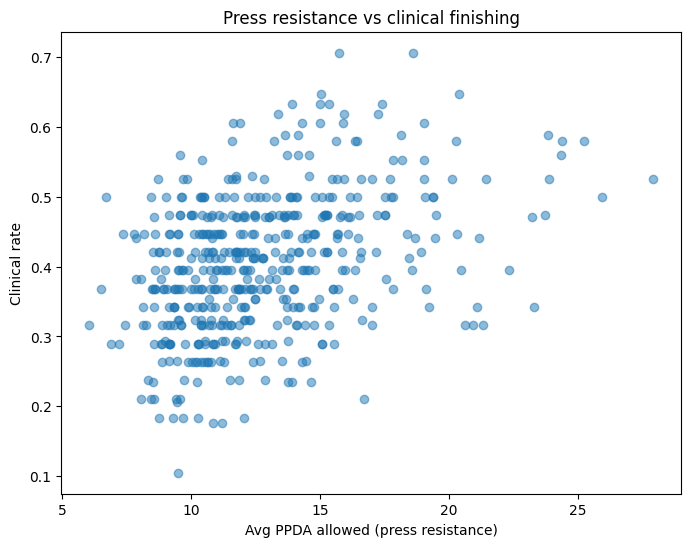

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(press_resistance['avg_ppda_allowed'], press_resistance['clinical_rate'], alpha=0.5)
plt.xlabel('Avg PPDA allowed (press resistance)')
plt.ylabel('Clinical rate')
plt.title('Press resistance vs clinical finishing')
plt.show()


In [31]:
zone_profile = ppda_clean.groupby(['team_name', 'league', 'year']).agg(
    avg_ppda=('ppda_value', 'mean'),
    avg_deep_allowed=('deep_allowed', 'mean')
).reset_index()

print(zone_profile.corr(numeric_only=True))

                      year  avg_ppda  avg_deep_allowed
year              1.000000  0.106422          0.109973
avg_ppda          0.106422  1.000000          0.553356
avg_deep_allowed  0.109973  0.553356          1.000000


In [32]:
zone_profile['pressing_profile'] = pd.cut(
    zone_profile['avg_ppda'],
    bins=[0, 10, 14, 100],
    labels=['high_press', 'mid_block', 'low_block']
)

profile_summary = zone_profile.groupby('pressing_profile').agg(
    teams=('team_name', 'count'),
    avg_ppda=('avg_ppda', 'mean'),
    avg_deep_allowed=('avg_deep_allowed', 'mean')
).round(2)

print(profile_summary)

                  teams  avg_ppda  avg_deep_allowed
pressing_profile                                   
high_press           77      8.94              5.11
mid_block           268     12.10              6.18
low_block           141     15.68              7.48


In [33]:
print(team_season.columns.tolist())

['team_name', 'league', 'year', 'games_played', 'scored', 'missed', 'xG', 'xGA', 'match_xGD', 'match_npxGD', 'dominance', 'xGD_magnitude', 'dominance_gap', 'gk_save_ratio', 'goals_vs_xG_ratio_team', 'clinical', 'ultra_clinical', 'wasteful', 'ultra_wasteful', 'heist', 'grand_heist', 'robbery', 'grand_robbery', 'dominant_win', 'dropped_points', 'stolen_point', 'heroic_defence', 'gk_worldie', 'gk_nightmare', 'home_bottled', 'away_heist', 'fortress', 'perfect_heist', 'cruel', 'xGD_attack', 'xGD_defence', 'clinical_rate', 'heist_rate', 'robbery_rate', 'wasteful_rate', 'xG_per_game', 'xGA_per_game', 'goals_per_game', 'conceded_per_game', 'xGD_per_game', 'xGD_attack_zscore', 'xGD_defence_zscore', 'heist_rate_zscore', 'clinical_rate_zscore', 'robbery_rate_zscore', 'xGD_attack_rank', 'heist_rate_rank']


In [34]:
print(teams_df[['team_name', 'league', 'year', 'pts']].head())
print()
print(teams_df.groupby(['team_name', 'league', 'year'])['pts'].sum().head())

       team_name      league  year  pts
0  Bayern Munich  bundesliga  2020    3
1  Bayern Munich  bundesliga  2020    0
2  Bayern Munich  bundesliga  2020    3
3  Bayern Munich  bundesliga  2020    3
4  Bayern Munich  bundesliga  2020    3

team_name  league   year
AC Milan   serie_a  2020    79
                    2021    86
                    2022    70
                    2023    75
                    2024    63
Name: pts, dtype: int64


In [35]:
season_standings = teams_df.groupby(['team_name', 'league', 'year'])['pts'].sum().reset_index()

season_standings['tier_rank'] = season_standings.groupby(['league', 'year'])['pts'].rank(ascending=False, method='first')
season_standings['league_size'] = season_standings.groupby(['league', 'year'])['team_name'].transform('count')

season_standings['opponent_tier'] = pd.cut(
    season_standings['tier_rank'] / season_standings['league_size'],
    bins=[0, 0.333, 0.667, 1.0],
    labels=['top', 'mid', 'bottom']
)

print(season_standings.head(10))
print()
print(season_standings['opponent_tier'].value_counts())

  team_name   league  year  pts  tier_rank  league_size opponent_tier
0  AC Milan  serie_a  2020   79        2.0           20           top
1  AC Milan  serie_a  2021   86        1.0           20           top
2  AC Milan  serie_a  2022   70        5.0           20           top
3  AC Milan  serie_a  2023   75        2.0           20           top
4  AC Milan  serie_a  2024   63        8.0           20           mid
5   Ajaccio  ligue_1  2022   26       18.0           20        bottom
6    Alaves  la_liga  2020   38       15.0           20        bottom
7    Alaves  la_liga  2021   31       20.0           20        bottom
8    Alaves  la_liga  2023   46       10.0           20           mid
9    Alaves  la_liga  2024   42       13.0           20           mid

opponent_tier
mid       175
bottom    168
top       143
Name: count, dtype: int64


In [37]:
clinical_df = pd.read_csv('../data/processed/clinical_games.csv')
print(clinical_df.columns.tolist())

['h_a', 'xG', 'xGA', 'npxG', 'npxGA', 'ppda', 'ppda_allowed', 'deep', 'deep_allowed', 'scored', 'missed', 'xpts', 'result', 'date', 'wins', 'draws', 'loses', 'pts', 'npxGD', 'team_id', 'team_name', 'league', 'year', 'datetime', 'match_id', 'home_team', 'away_team', 'match_xGD', 'match_npxGD', 'xGA_diff', 'dominance', 'clinical', 'ultra_clinical', 'wasteful', 'ultra_wasteful', 'expected', 'heist', 'grand_heist', 'robbery', 'grand_robbery', 'dropped_points', 'stolen_point', 'dominant_win', 'match_total_goals', 'chaos', 'ghost', 'keepers_day', 'paradise_day', 'xGD_magnitude', 'dominance_gap', 'goals_vs_xG_ratio', 'goals_vs_xG_ratio_team', 'gk_save_ratio', 'xG_total', 'heroic_defence', 'routine_clean_sheet', 'defensive_collapse', 'gk_worldie', 'gk_nightmare', 'away_win', 'away_heist', 'home_bottled', 'perfect_heist', 'cruel', 'fortress', 'momentum_collapse', 'false_dominance', 'smash_and_grab', 'dead_rubber', 'AT', 'Q1', 'Q2', 'Q3', 'Q4', 'opp_AT_xG', 'opp_Q1_xG', 'opp_Q2_xG', 'opp_Q3_xG',

/var/folders/c3/hm5hq4r93ygcpfzfc4gv1mkh0000gn/T/ipykernel_64569/104994610.py:1: DtypeWarning: Columns (0: derby_name) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_df = pd.read_csv('../data/processed/clinical_games.csv')


In [38]:
clinical_df['opponent_name'] = np.where(
    clinical_df['h_a'] == 'h',
    clinical_df['away_team'],
    clinical_df['home_team']
)

# tag each match's opponent tier
clinical_df = clinical_df.merge(
    season_standings[['team_name', 'league', 'year', 'opponent_tier']].rename(
        columns={'team_name': 'opponent_name', 'opponent_tier': 'opp_tier'}
    ),
    on=['opponent_name', 'league', 'year'],
    how='left'
)

print(clinical_df[['team_name', 'opponent_name', 'opp_tier']].head(10))
print()
print(clinical_df['opp_tier'].value_counts(dropna=False))

  team_name opponent_name opp_tier
0  AC Milan       Bologna      mid
1  AC Milan       Crotone   bottom
2  AC Milan        Spezia   bottom
3  AC Milan         Inter      top
4  AC Milan          Roma      mid
5  AC Milan       Udinese   bottom
6  AC Milan        Verona      mid
7  AC Milan        Napoli      top
8  AC Milan    Fiorentina      mid
9  AC Milan     Sampdoria      mid

opp_tier
mid       6454
bottom    6216
top       5294
Name: count, dtype: int64


In [39]:
opponent_adjusted = clinical_df.groupby(['team_name', 'league', 'year', 'opp_tier']).agg(
    matches=('match_xGD', 'count'),
    avg_xGD=('match_xGD', 'mean')
).reset_index()

opponent_pivot = opponent_adjusted.pivot_table(
    index=['team_name', 'league', 'year'],
    columns='opp_tier',
    values='avg_xGD'
).reset_index()

opponent_pivot['bully_gap'] = opponent_pivot['bottom'] - opponent_pivot['top']

print(opponent_pivot.sort_values('bully_gap', ascending=False).head(10))
print()
print(opponent_pivot.sort_values('bully_gap', ascending=True).head(10))

opp_tier                team_name          league  year       top       mid  \
292                        Monaco         ligue_1  2022 -0.416004 -0.124804   
334           Paris Saint Germain         ligue_1  2021 -0.416737  0.123814   
380                          Roma         serie_a  2023 -0.330831  0.097698   
485       Wolverhampton Wanderers  premier_league  2024 -0.268950  0.252388   
275               Manchester City  premier_league  2023 -0.570726  0.496457   
237                          Lens         ligue_1  2021 -0.073505 -0.122916   
425                     Tottenham  premier_league  2022 -0.075929  0.084661   
374                        Rennes         ligue_1  2022 -0.272730 -0.094847   
167                    Fiorentina         serie_a  2022 -0.509060 -0.273475   
373                        Rennes         ligue_1  2021 -0.101171  0.258970   

opp_tier    bottom  bully_gap  
292       0.753276   1.169280  
334       0.721311   1.138048  
380       0.716030   1.046861  
48

In [40]:
match_counts = opponent_adjusted.pivot_table(
    index=['team_name', 'league', 'year'],
    columns='opp_tier',
    values='matches'
)
print(match_counts.loc[[('Manchester City', 'premier_league', 2023), ('Paris Saint Germain', 'ligue_1', 2021)]])
print()
print(match_counts.describe())

opp_tier                                  top   mid  bottom
team_name           league         year                    
Manchester City     premier_league 2023  10.0  14.0    14.0
Paris Saint Germain ligue_1        2021  10.0  14.0    14.0

opp_tier         top         mid      bottom
count     486.000000  486.000000  486.000000
mean       10.893004   13.279835   12.790123
std         1.252162    0.961037    1.284798
min         8.000000   12.000000   10.000000
25%        10.000000   12.000000   12.000000
50%        12.000000   14.000000   12.000000
75%        12.000000   14.000000   14.000000
max        12.000000   14.000000   14.000000


In [41]:
print(opponent_pivot[['top', 'mid', 'bottom']].mean())

opp_tier
top      -0.080591
mid      -0.066197
bottom    0.011450
dtype: float64


In [42]:
baseline_gap = opponent_pivot['bottom'].mean() - opponent_pivot['top'].mean()
print(f"League-wide baseline gap: {baseline_gap:.3f}")

opponent_pivot['excess_bully_gap'] = opponent_pivot['bully_gap'] - baseline_gap

print(opponent_pivot.sort_values('excess_bully_gap', ascending=False)[['team_name', 'league', 'year', 'top', 'bottom', 'bully_gap', 'excess_bully_gap']].head(10))

League-wide baseline gap: 0.092
opp_tier                team_name          league  year       top    bottom  \
292                        Monaco         ligue_1  2022 -0.416004  0.753276   
334           Paris Saint Germain         ligue_1  2021 -0.416737  0.721311   
380                          Roma         serie_a  2023 -0.330831  0.716030   
485       Wolverhampton Wanderers  premier_league  2024 -0.268950  0.693618   
275               Manchester City  premier_league  2023 -0.570726  0.372008   
237                          Lens         ligue_1  2021 -0.073505  0.865782   
425                     Tottenham  premier_league  2022 -0.075929  0.861530   
374                        Rennes         ligue_1  2022 -0.272730  0.629733   
167                    Fiorentina         serie_a  2022 -0.509060  0.391871   
373                        Rennes         ligue_1  2021 -0.101171  0.796065   

opp_tier  bully_gap  excess_bully_gap  
292        1.169280          1.077240  
334        1.13804

In [43]:
print(clinical_df[['team_name', 'league', 'year', 'date', 'fatigue_game', 'is_derby']].head())

  team_name   league  year                 date      fatigue_game  is_derby
0  AC Milan  serie_a  2020  2020-09-21 18:45:00  not_fatigue_game     False
1  AC Milan  serie_a  2020  2020-09-27 16:00:00  not_fatigue_game     False
2  AC Milan  serie_a  2020  2020-10-04 16:00:00  not_fatigue_game     False
3  AC Milan  serie_a  2020  2020-10-17 16:00:00  not_fatigue_game      True
4  AC Milan  serie_a  2020  2020-10-26 19:45:00  not_fatigue_game     False


In [44]:
print(teams_df[['team_name', 'league', 'year', 'date']].head())

       team_name      league  year                 date
0  Bayern Munich  bundesliga  2020  2020-09-18 18:30:00
1  Bayern Munich  bundesliga  2020  2020-09-27 13:30:00
2  Bayern Munich  bundesliga  2020  2020-10-04 16:00:00
3  Bayern Munich  bundesliga  2020  2020-10-17 16:30:00
4  Bayern Munich  bundesliga  2020  2020-10-24 13:30:00


In [45]:
ppda_fatigue_derby = teams_df.merge(
    clinical_df[['team_name', 'league', 'year', 'date', 'fatigue_game', 'is_derby']],
    on=['team_name', 'league', 'year', 'date'],
    how='inner'
)

print(ppda_fatigue_derby.shape, teams_df.shape)

(17964, 29) (17964, 27)


In [46]:
fatigue_ppda = ppda_fatigue_derby.groupby('fatigue_game')['ppda_value'].agg(['mean', 'median', 'count']).round(2)
print(fatigue_ppda)

print()
derby_ppda = ppda_fatigue_derby.groupby('is_derby')['ppda_value'].agg(['mean', 'median', 'count']).round(2)
print(derby_ppda)

                   mean  median  count
fatigue_game                          
fatigue_game      12.42   10.97   2357
not_fatigue_game  12.83   11.27  15605

           mean  median  count
is_derby                      
False     12.76   11.20  17682
True      13.52   12.16    280


In [48]:
# clinical_df has heist flag per match (as a string, remember from Notebook 02)
print(clinical_df['heist'].unique())

<ArrowStringArray>
['not_heist', 'heist']
Length: 2, dtype: str


In [49]:
match_level = teams_df.merge(
    clinical_df[['team_name', 'league', 'year', 'date', 'heist']],
    on=['team_name', 'league', 'year', 'date'],
    how='inner'
)

heist_match_ppda = match_level.groupby('heist')['ppda_value'].agg(['mean', 'median', 'count']).round(2)
print(heist_match_ppda)

            mean  median  count
heist                          
heist      13.85   12.59   1355
not_heist  12.68   11.11  16607


In [50]:
heist_by_league = match_level.groupby(['league', 'heist'])['ppda_value'].mean().unstack().round(2)
heist_by_league['gap'] = heist_by_league['heist'] - heist_by_league['not_heist']
print(heist_by_league)

heist           heist  not_heist   gap
league                                
bundesliga      15.10      13.15  1.95
la_liga         12.54      11.54  1.00
ligue_1         14.56      12.79  1.77
premier_league  13.63      13.27  0.36
serie_a         13.85      12.77  1.08


In [51]:
print(teams_df['result'].value_counts())

result
w    6701
l    6701
d    4562
Name: count, dtype: int64


In [52]:
result_ppda = ppda_clean.groupby('result')['ppda_value'].agg(['mean', 'median', 'count']).round(2)
print(result_ppda)

         mean  median  count
result                      
d       12.15   10.74   4555
l       13.51   11.78   6662
w       12.05   11.00   6697


In [53]:
print([v for v in dir() if not v.startswith('_')])

['In', 'Out', 'ast', 'baseline_gap', 'clinical_df', 'counter_goals', 'counter_only', 'counts', 'derby_ppda', 'exit', 'fatigue_ppda', 'get_ipython', 'heist_by_league', 'heist_match_ppda', 'heist_ppda', 'match_counts', 'match_level', 'np', 'open', 'opponent_adjusted', 'opponent_pivot', 'parse_ppda', 'pd', 'plt', 'ppda_allowed_season', 'ppda_by_league', 'ppda_by_league_clean', 'ppda_clean', 'ppda_fatigue_derby', 'press_resistance', 'pressing_actions', 'pressing_by_state', 'pressing_correlation', 'pressing_counter', 'pressing_pct', 'profile_summary', 'quit', 'result_ppda', 'sample_key', 'sample_match', 'sample_rows', 'season_standings', 'shots_df', 'shots_with_ppda', 'stability_heist', 'stability_results', 'team_counter_share', 'team_ppda_stability', 'team_season', 'team_season_ppda', 'team_tier_conversion', 'team_tier_summary', 'teams_df', 'tier_conversion', 'total_by_state', 'zone_profile']


In [54]:
def build_pressing_rag(league):
    league_ppda = ppda_by_league_clean.loc[league]
    league_zone = profile_summary  # global, not per-league — will note that
    league_heist_gap = heist_by_league.loc[league]
    
    # league-specific team-season stability extremes
    league_stability = team_ppda_stability[team_ppda_stability['league'] == league].sort_values('ppda_cv', ascending=False)
    most_reactive = league_stability.iloc[0]
    most_consistent = league_stability.iloc[-1]
    
    # league-specific press resistance
    league_resist = press_resistance[press_resistance['league'] == league]
    resist_corr_clinical = league_resist[['avg_ppda_allowed', 'clinical_rate']].corr().iloc[0,1]
    
    # league-specific flat-track bully leader
    league_bully = opponent_pivot[opponent_pivot['league'] == league].sort_values('excess_bully_gap', ascending=False)
    top_bully = league_bully.iloc[0]
    
    block = f"""
LEAGUE: {league.replace('_', ' ').title()}

PRESSING INTENSITY:
avg_ppda={league_ppda['mean']:.2f} | median_ppda={league_ppda['median']:.2f} | std={league_ppda['std']:.2f}
NOTE: lower PPDA = more aggressive pressing (fewer opponent passes allowed before defensive action)

PPDA VS ATTACKING OUTPUT (global, all leagues):
correlation_with_xGD_attack=0.021 (near zero — REJECTED, pressing intensity alone does not predict attacking output)
correlation_with_clinical_rate=-0.148 (weak — REJECTED)
correlation_with_shot_volume=-0.524 (CONFIRMED — high press teams average 530 shots/season vs 411 for low-block teams)
shot_quality_by_press_tier: high_press_conversion=11.5% | low_block_conversion=10.2% (CONFIRMED, modest)

PRESSING STABILITY (season-to-season match variance, ppda_cv):
most_reactive_team: {most_reactive['team_name']} {int(most_reactive['year'])} (cv={most_reactive['ppda_cv']:.3f})
most_consistent_team: {most_consistent['team_name']} {int(most_consistent['year'])} (cv={most_consistent['ppda_cv']:.3f})
FINDING: pressing consistency does not predict results, xGD, or heist_rate (all correlations <0.16) — REJECTED

DESPERATION PRESSING (global, whole-match level):
losing_matches_avg_ppda=13.51 | winning_matches_avg_ppda=12.05 | drawing_matches_avg_ppda=12.15
FINDING: losing teams show weaker pressing throughout the match (CONFIRMED, revised from initial shot-proxy test)
WITHIN-MATCH TRAJECTORY: pressing-turnover shot share for losing teams declines from 4.18% (Q1) to 1.49% (added time) — teams fade further, do not rally the press late

PRESS RESISTANCE (this league):
correlation_ppda_allowed_vs_clinical_rate={resist_corr_clinical:.3f}
GLOBAL: correlation=0.394 with clinical_rate, 0.206 with xGD_attack — CONFIRMED, strongest team-level finding in notebook
INSIGHT: how well a team resists being pressed matters more for attacking output than how aggressively that team presses others

ZONE-BASED PRESSING (global):
high_press_deep_completions_allowed=5.11 | mid_block=6.18 | low_block=7.48
FINDING: high pressing meaningfully reduces deep completions allowed (CONFIRMED, correlation=0.553) — the cleanest mechanistic finding in the notebook

FLAT-TRACK BULLY DETECTION (this league):
top_flat_track_bully: {top_bully['team_name']} {int(top_bully['year'])} — xGD vs bottom-tier opponents={top_bully['bottom']:+.2f}, vs top-tier opponents={top_bully['top']:+.2f}, excess_gap={top_bully['excess_bully_gap']:.3f}
NOTE: baseline_gap_all_teams=0.092 — a raw bully_gap must exceed this to be a genuine signal, not just the universal effect of facing weaker opposition

FATIGUE AND DERBY EFFECTS (global, both counterintuitive):
fatigue_games_avg_ppda=12.42 vs normal_games=12.83 — teams press MARGINALLY MORE, not less, when fatigued (REJECTED original hypothesis, reversed)
derby_avg_ppda=13.52 vs non_derby=12.76 — teams press LESS aggressively in derbies, more cautious not more frantic (REJECTED original hypothesis, reversed)

PARK THE BUS AND NICK ONE (this league):
heist_match_avg_ppda={league_heist_gap['heist']:.2f} | non_heist_avg_ppda={league_heist_gap['not_heist']:.2f} | gap={league_heist_gap['gap']:.2f}
GLOBAL: confirmed in all 5 leagues; Bundesliga shows strongest effect (gap=1.95), Premier League weakest (gap=0.36)
FINDING: teams genuinely sit deeper specifically in matches where they achieve a heist result — but this was invisible at season-aggregate level (correlation=0.095) and only appeared when tested match-by-match. Aggregation dilutes situational tactical patterns.

INSIGHT: {league.replace('_',' ').title()} teams press at {league_ppda['mean']:.2f} PPDA on average. The strongest predictor of attacking success in this league is not how hard a team presses, but how well it resists being pressed (r={resist_corr_clinical:.2f} with clinical finishing). {top_bully['team_name']}'s {int(top_bully['year'])} season stands out as the league's clearest flat-track-bully profile, dominating weak sides while struggling against genuine quality.
"""
    return block.strip()

for league in ppda_by_league_clean.index:
    text = build_pressing_rag(league)
    with open(f'../data/rag_findings/pressing_{league}.txt', 'w') as f:
        f.write(text)
    print(f"saved {league}")

print(build_pressing_rag('bundesliga'))

saved bundesliga
saved la_liga
saved ligue_1
saved premier_league
saved serie_a
LEAGUE: Bundesliga

PRESSING INTENSITY:
avg_ppda=13.17 | median_ppda=11.73 | std=6.46
NOTE: lower PPDA = more aggressive pressing (fewer opponent passes allowed before defensive action)

PPDA VS ATTACKING OUTPUT (global, all leagues):
correlation_with_xGD_attack=0.021 (near zero — REJECTED, pressing intensity alone does not predict attacking output)
correlation_with_clinical_rate=-0.148 (weak — REJECTED)
correlation_with_shot_volume=-0.524 (CONFIRMED — high press teams average 530 shots/season vs 411 for low-block teams)
shot_quality_by_press_tier: high_press_conversion=11.5% | low_block_conversion=10.2% (CONFIRMED, modest)

PRESSING STABILITY (season-to-season match variance, ppda_cv):
most_reactive_team: Hertha Berlin 2020 (cv=0.667)
most_consistent_team: Wolfsburg 2020 (cv=0.302)
FINDING: pressing consistency does not predict results, xGD, or heist_rate (all correlations <0.16) — REJECTED

DESPERATION PR

In [57]:
import json

with open('../eval/eval_questions.json', 'r') as f:
    eval_questions = json.load(f)

print(f"Current total: {len(eval_questions)}")

Current total: 20


In [58]:
with open('../eval/eval_questions.json', 'r') as f:
    eval_questions = json.load(f)

print(f"Current total: {len(eval_questions)}")

new_questions = [
    {
        "question": "Does pressing intensity (PPDA) predict a team's attacking output?",
        "tool": "RAG",
        "answer": "No — correlation with xGD_attack is near zero (0.021). Pressing intensity alone does not predict attacking quality."
    },
    {
        "question": "What actually predicts good attacking output related to pressing?",
        "tool": "RAG",
        "answer": "Press resistance (ppda_allowed) — how well a team resists being pressed correlates 0.394 with clinical finishing and 0.206 with xGD_attack, both stronger than the team's own pressing intensity"
    },
    {
        "question": "Do teams press harder when losing, to chase the game?",
        "tool": "RAG",
        "answer": "No — losing teams show weaker pressing throughout the match (13.51 avg PPDA vs ~12.1 for wins/draws), and pressing-driven shots decline further as added time approaches rather than intensifying"
    },
    {
        "question": "Which league shows the strongest 'park the bus and nick one' pattern for heists?",
        "tool": "RAG",
        "answer": "Bundesliga — teams show the largest PPDA gap (1.95) between heist matches and normal matches, meaning German sides sit deepest specifically when pulling off a heist result"
    },
    {
        "question": "Does high pressing actually reduce the danger a team concedes?",
        "tool": "RAG",
        "answer": "Yes — high-press teams concede an average of 5.11 deep completions per match vs 7.48 for low-block teams, a strong correlation (0.553) confirming the press functionally disrupts opponent buildup"
    },
    {
        "question": "Which team had the clearest flat-track bully profile?",
        "tool": "RAG",
        "answer": "PSG 2021 — after correcting for the league-wide baseline effect of facing weaker opponents, PSG showed the largest excess gap (1.05) between dominating bottom-tier teams and struggling against top-tier opposition"
    }
]

eval_questions.extend(new_questions)

with open('../eval/eval_questions.json', 'w') as f:
    json.dump(eval_questions, f, indent=2)

print(f"Total questions now: {len(eval_questions)}")

Current total: 20
Total questions now: 26


In [61]:
shots_df = pd.read_csv('../data/processed/shots_enriched.csv')

rosters_df['team_name'] = np.where(
    rosters_df['h_a'] == 'h',
    rosters_df['match_id'].map(shots_df.drop_duplicates('match_id').set_index('match_id')['h_team']),
    rosters_df['match_id'].map(shots_df.drop_duplicates('match_id').set_index('match_id')['a_team'])
)

print(rosters_df['team_name'].isna().sum(), 'unmatched rows')

rosters_ppda = rosters_df.merge(
    team_season_ppda[['team_name', 'league', 'year', 'ppda_tier']],
    on=['team_name', 'league', 'year'],
    how='inner'
)

print(rosters_ppda.shape, rosters_df.shape)

0 unmatched rows
(273825, 26) (273825, 25)


In [62]:
position_ppda_profile = rosters_ppda.groupby(['position', 'ppda_tier']).agg(
    appearances=('position', 'count'),
    avg_xGBuildup=('xGBuildup', 'mean'),
    avg_xGChain=('xGChain', 'mean')
).round(3)

print(position_ppda_profile)

                     appearances  avg_xGBuildup  avg_xGChain
position ppda_tier                                          
AMC      high_press         1831          0.255        0.548
         mid_block          6210          0.223        0.482
         low_block          3139          0.164        0.369
AML      high_press          989          0.227        0.580
         mid_block          2644          0.188        0.449
         low_block          1248          0.144        0.365
AMR      high_press          989          0.255        0.574
         mid_block          2644          0.189        0.437
         low_block          1248          0.138        0.369
DC       high_press         6275          0.316        0.331
         mid_block         23343          0.239        0.253
         low_block         12552          0.170        0.184
DL       high_press         2326          0.320        0.401
         mid_block          6904          0.243        0.312
         low_block      

In [63]:
ratio_check = position_ppda_profile.reset_index().pivot(index='position', columns='ppda_tier', values='avg_xGBuildup')
ratio_check['high_to_low_ratio'] = (ratio_check['high_press'] / ratio_check['low_block']).round(2)
print(ratio_check.sort_values('high_to_low_ratio', ascending=False))

ppda_tier  high_press  mid_block  low_block  high_to_low_ratio
position                                                      
DR              0.331      0.242      0.176               1.88
FWR             0.281      0.193      0.150               1.87
FWL             0.255      0.194      0.137               1.86
DC              0.316      0.239      0.170               1.86
AMR             0.255      0.189      0.138               1.85
MC              0.341      0.254      0.186               1.83
DL              0.320      0.243      0.183               1.75
Sub             0.085      0.063      0.049               1.73
GK              0.156      0.121      0.091               1.71
FW              0.169      0.126      0.100               1.69
DML             0.280      0.212      0.171               1.64
DMC             0.343      0.285      0.212               1.62
AML             0.227      0.188      0.144               1.58
AMC             0.255      0.223      0.164            

In [64]:
def add_position_section(league):
    # rebuild the file with position data appended
    with open(f'../data/rag_findings/pressing_{league}.txt', 'r') as f:
        existing = f.read()
    
    position_section = f"""

POSITION-LEVEL PRESSING SENSITIVITY (global, all leagues):
Every position shows more xGBuildup/xGChain involvement at high-press teams vs low-block teams — 
driven by overall possession share, not distinct tactical roles.

MOST SENSITIVE TO TEAM PRESSING STYLE (largest high-press/low-block ratio):
DR (right-back): {ratio_check.loc['DR','high_press']:.3f} vs {ratio_check.loc['DR','low_block']:.3f} (ratio={ratio_check.loc['DR','high_to_low_ratio']:.2f}x)
DC (center-back): {ratio_check.loc['DC','high_press']:.3f} vs {ratio_check.loc['DC','low_block']:.3f} (ratio={ratio_check.loc['DC','high_to_low_ratio']:.2f}x)
DL (left-back): {ratio_check.loc['DL','high_press']:.3f} vs {ratio_check.loc['DL','low_block']:.3f} (ratio={ratio_check.loc['DL','high_to_low_ratio']:.2f}x)

LEAST SENSITIVE (buildup role stable regardless of team pressing style):
DMR: ratio={ratio_check.loc['DMR','high_to_low_ratio']:.2f}x
MR: ratio={ratio_check.loc['MR','high_to_low_ratio']:.2f}x
ML: ratio={ratio_check.loc['ML','high_to_low_ratio']:.2f}x

INSIGHT: defenders and fullbacks are the positions most dependent on a team's overall pressing/possession 
identity — their attacking involvement swings most between passive and aggressive systems (1.75-1.88x), 
while defensive/wide midfielders maintain stable buildup roles regardless of tactical style (1.43-1.62x). 
This confirms the Notebook 03 finding that high-xGBuildup defenders concede more counters isn't a defender-specific 
tactical flaw — it's a byproduct of the same possession-share effect that elevates every position's involvement 
at high-press teams.
"""
    
    updated = existing + position_section
    with open(f'../data/rag_findings/pressing_{league}.txt', 'w') as f:
        f.write(updated)
    print(f"updated {league}")

for league in ppda_by_league_clean.index:
    add_position_section(league)

# verify
with open('../data/rag_findings/pressing_bundesliga.txt', 'r') as f:
    print(f.read())

updated bundesliga
updated la_liga
updated ligue_1
updated premier_league
updated serie_a
LEAGUE: Bundesliga

PRESSING INTENSITY:
avg_ppda=13.17 | median_ppda=11.73 | std=6.46
NOTE: lower PPDA = more aggressive pressing (fewer opponent passes allowed before defensive action)

PPDA VS ATTACKING OUTPUT (global, all leagues):
correlation_with_xGD_attack=0.021 (near zero — REJECTED, pressing intensity alone does not predict attacking output)
correlation_with_clinical_rate=-0.148 (weak — REJECTED)
correlation_with_shot_volume=-0.524 (CONFIRMED — high press teams average 530 shots/season vs 411 for low-block teams)
shot_quality_by_press_tier: high_press_conversion=11.5% | low_block_conversion=10.2% (CONFIRMED, modest)

PRESSING STABILITY (season-to-season match variance, ppda_cv):
most_reactive_team: Hertha Berlin 2020 (cv=0.667)
most_consistent_team: Wolfsburg 2020 (cv=0.302)
FINDING: pressing consistency does not predict results, xGD, or heist_rate (all correlations <0.16) — REJECTED

DESP